## Imports

In [1]:
import zipfile as zf
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.io import loadmat
import io

In [2]:
zip_train = "mnist_img_train.txt.zip"
zip_test = "mnist_img_test.txt.zip"
try: 
    with zf.ZipFile(zip_train, 'r') as files:
        files.extractall()
except FileNotFoundError: print(f"Error: {zip_train} not found")
try: 
    with zf.ZipFile(zip_test, 'r') as files2:
        files2.extractall()
except FileNotFoundError: print(f"Error: {zip_test} not found")

In [3]:
input_train = open('mnist_img_train.txt', 'r')
input_train_lines = input_train.readlines()
input_train.close()
train_x = np.array([[int (r) for r in i.split(" ")] for i in input_train_lines])

input_test = open('mnist_img_test.txt', 'r')
input_test_lines = input_test.readlines()
input_test.close()
test_x = np.array([[int (r) for r in i.split(" ")] for i in input_test_lines])

base_path = r"C:\Users\andyk\Downloads\FEA_displacement_results_step12"

train_disp_x = np.loadtxt(base_path + r"\summary_dispx_train_step12.txt")
train_disp_y = np.loadtxt(base_path + r"\summary_dispy_train_step12.txt")

test_disp_x = np.loadtxt(base_path + r"\summary_dispx_test_step12.txt")
test_disp_y = np.loadtxt(base_path + r"\summary_dispy_test_step12.txt")

train_dy = np.hstack([train_disp_x, train_disp_y])
test_dy = np.hstack([test_disp_x, test_disp_y])

print("train displacement shape:", train_dy.shape)
print("test displacement shape:", test_dy.shape)
print("train bitmap shape:", train_x.shape)
print("test bitmap shape:", test_x.shape)

train displacement shape: (60000, 1568)
test displacement shape: (10000, 1568)
train bitmap shape: (60000, 784)
test bitmap shape: (10000, 784)


Training complete after 39 iterations.

MSE per epoch (training):
  Epoch   1: MSE = 1268.567632
  Epoch   2: MSE = 801.876732
  Epoch   3: MSE = 695.513764
  Epoch   4: MSE = 635.809234
  Epoch   5: MSE = 598.595307
  Epoch   6: MSE = 573.378113
  Epoch   7: MSE = 553.559959
  Epoch   8: MSE = 538.531947
  Epoch   9: MSE = 526.863478
  Epoch  10: MSE = 517.009037
  Epoch  11: MSE = 508.311489
  Epoch  12: MSE = 502.526967
  Epoch  13: MSE = 495.224891
  Epoch  14: MSE = 490.347581
  Epoch  15: MSE = 486.203891
  Epoch  16: MSE = 481.616268
  Epoch  17: MSE = 478.219000
  Epoch  18: MSE = 475.221111
  Epoch  19: MSE = 471.690801
  Epoch  20: MSE = 469.382271
  Epoch  21: MSE = 466.841706
  Epoch  22: MSE = 464.501925
  Epoch  23: MSE = 462.000869
  Epoch  24: MSE = 459.907400
  Epoch  25: MSE = 458.333578
  Epoch  26: MSE = 456.625426
  Epoch  27: MSE = 454.587321
  Epoch  28: MSE = 453.580641
  Epoch  29: MSE = 452.894309
  Epoch  30: MSE = 450.644956
  Epoch  31: MSE = 449.745362
  E

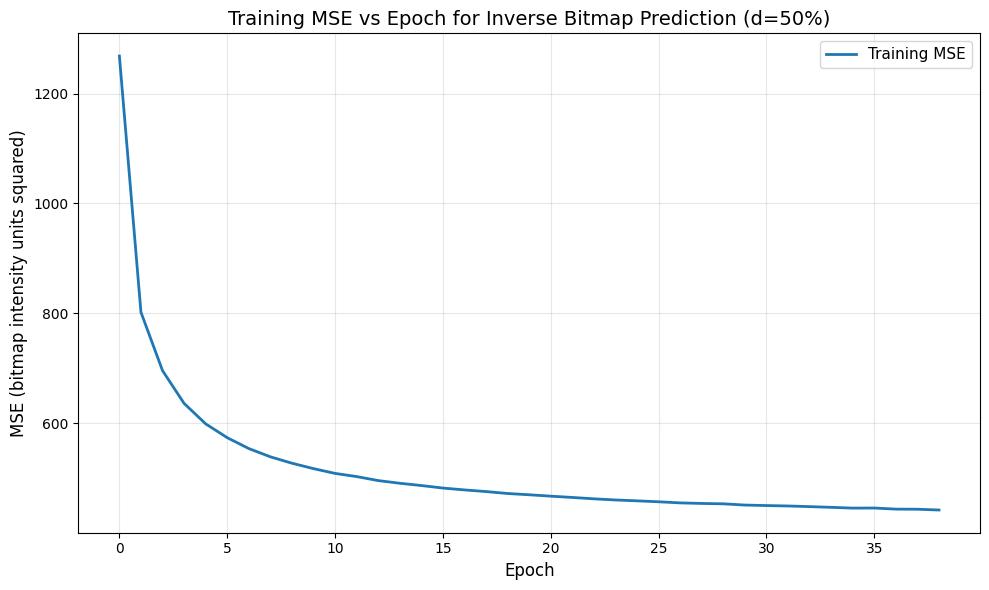


Final MAE on Test Set: 16.3800 bitmap intensity units


In [7]:
scaler = StandardScaler()
train_dy_scaled = scaler.fit_transform(train_dy)
test_dy_scaled = scaler.transform(test_dy)

mlp_inv = MLPRegressor(hidden_layer_sizes=(256, 128, 64), activation="relu", solver="adam", learning_rate_init=0.005, max_iter=500, tol=1e-5, 
                       n_iter_no_change=20, early_stopping=True, validation_fraction=0.1, random_state=42, verbose=False)

mlp_inv.fit(train_dy_scaled, train_x)
print(f"Training complete after {mlp_inv.n_iter_} iterations.\n")

train_bitmap_pred = mlp_inv.predict(train_dy_scaled)
test_bitmap_pred  = mlp_inv.predict(test_dy_scaled)

print("MSE per epoch (training):")
for epoch, mse in enumerate(mlp_inv.loss_curve_, start=1): print(f"  Epoch {epoch:3d}: MSE = {mse:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(mlp_inv.loss_curve_, label='Training MSE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE (bitmap intensity units squared)', fontsize=12)
plt.title('Training MSE vs Epoch for Inverse Bitmap Prediction (d=50%)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

test_mae = mean_absolute_error(test_x, test_bitmap_pred)
print(f"\nFinal MAE on Test Set: {test_mae:.4f} bitmap intensity units")

The inverse design problem uses the displacement field as the input, and uses the 28x28 bitmap as output (the target). This MLP architecture is the same as the forward model in the previous problem used. The activation function is ReLU, and the solver is Adam. The learning rate is increased a bit to speed up convergence, a standard scaler is applied to the displacement field to normalize the feature scale before training, early stopping is used with a tolerance threshold and patience of 20 epochs without improvement to allow the model sufficient time to converge before stopping before the epoch maximum value. The MSE vs peoch curve shows the training loss in bitmap intensity units squared decreasing over epochs until the stopping point.

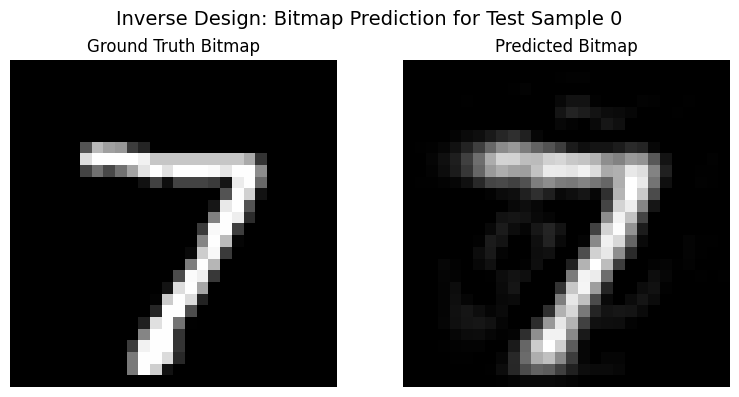

In [ ]:
true_bitmap = test_x[0].reshape(28, 28)
pred_bitmap = test_bitmap_pred[0].reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle(f'Inverse Design: Bitmap Prediction for Test Sample 0', fontsize=14)
axes[0].imshow(true_bitmap, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Ground Truth Bitmap')
axes[0].axis('off')
axes[1].imshow(pred_bitmap, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Predicted Bitmap')
axes[1].axis('off')
plt.tight_layout()
plt.show()

The plot above, created with assistance from ChatGPT, compares the ground truth and the predicted bitmap side by side for the first test sample. The predicted image accurately captures the overall character of the digit, but the resolution on the edges is greatly reduced compared to the ground truth. The global shape and form of the number is recoverable from the information provided, but fine detail is lost. 

## EMNIST Letters

EMNIST displacement shape: (10, 1568)
EMNIST ground truth shape: (10, 784)
Letters: ['g', 'j', 'k', 'm', 'n', 'o', 'p', 'q', 's', 'x']

Mean Absolute Error on EMNIST Letters: 45.7179 bitmap intensity units
Mean Absolute Error on MNIST Test Set:  16.3800 bitmap intensity units


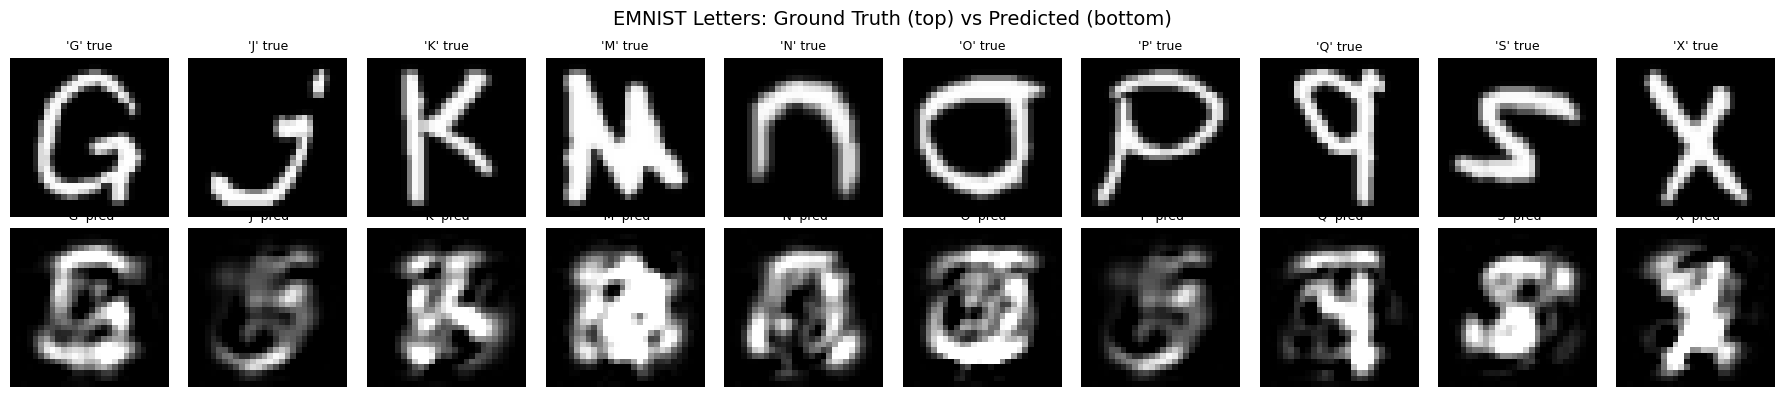

In [ ]:
letters = sorted(['j', 's', 'x', 'n', 'g', 'q', 'p', 'm', 'o', 'k'])

emnist_dy = np.zeros((len(letters), 1568))
emnist_true = np.zeros((len(letters),  784))

with zf.ZipFile('EMNIST-1.zip', 'r') as z:
    for i, letter in enumerate(letters):
        with z.open(f'{letter}U1U2.npz') as f:
            npz = np.load(io.BytesIO(f.read()))
            ux = npz['arr1'].flatten()
            uy = npz['arr2'].flatten()
            emnist_dy[i] = np.concatenate([ux, uy])
        with z.open(f'{letter}.mat') as f:
            mat = loadmat(io.BytesIO(f.read()))
            emnist_true[i] = mat['TrainData'].flatten()

print("EMNIST displacement shape:", emnist_dy.shape)
print("EMNIST ground truth shape:", emnist_true.shape)
print("Letters:", letters)

emnist_dy_scaled  = scaler.transform(emnist_dy)
emnist_bitmap_pred = mlp_inv.predict(emnist_dy_scaled)

emnist_mae = mean_absolute_error(emnist_true, emnist_bitmap_pred)
print(f"\nMean Absolute Error on EMNIST Letters: {emnist_mae:.4f} bitmap intensity units")
print(f"Mean Absolute Error on MNIST Test Set:  {test_mae:.4f} bitmap intensity units")

fig, axes = plt.subplots(2, len(letters), figsize=(18, 4))
fig.suptitle('EMNIST Letters: Ground Truth (top) vs Predicted (bottom)', fontsize=14)
for i, letter in enumerate(letters):
    axes[0, i].imshow(emnist_true[i].reshape(28, 28), cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f"'{letter.upper()}' true",  fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(emnist_bitmap_pred[i].reshape(28, 28), cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f"'{letter.upper()}' pred",  fontsize=9)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

The plot above shows the tested EMNIST letters: G, j, K, M, n, o,  p, q, s, X. This data was never shown to the model, as its training was on handwritten digits between 0-9. The model uses the same scaler from the previous problem, since the scaler was fit on the MNIST digits. The MAE on the EMNIST letters is almost triple than on the MNIST test set, which makes sense since this is an entirely new geometry for the model to ahndle. In a few images, we can make out a few coarse structures, like the highlights in X, G, and K. But the detail is entirely gone, and the bitmap highlights are sporadic for many shapes. Whereas the predicted structure in problem 3 looked like a lower resolution product of the ground truth, there is significant noise in the prediction bitmaps here. Adding some letter samples to the training or increasing the complexity of the initial model could help improve transferability, but this was not the goal of the problem. The goal was to see how the pretrained model could adapt to new geometries without transfer learning or fine tuning. 